In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [24]:
df = pd.read_csv("https://raw.githubusercontent.com/DataTalksClub/machine-learning-zoomcamp/main/cohorts/2026/data/car_fuel_efficiency_2026.csv")
df

,model_year,origin,fuel_type,drivetrain,num_doors,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,fuel_efficiency_mpg
0,2006,Europe,Gasoline,Front-wheel drive,4,2180,6,243.0,3870,NaN,31.9
1,2008,Europe,Diesel,Front-wheel drive,4,2390,6,272.0,4210,NaN,31.3
2,1996,Asia,Gasoline,Front-wheel drive,5,2320,6,267.0,4240,17.3,27.5
3,1989,Europe,Gasoline,Front-wheel drive,4,2130,6,258.0,4490,18.7,28.5
4,1994,USA,Diesel,Front-wheel drive,3,2580,7,304.0,4510,17.5,31.0
...,...,...,...,...,...,...,...,...,...,...,...
9995,2005,USA,Gasoline,All-wheel drive,4,2470,6,271.0,4690,18.9,27.4
9996,1993,Asia,Gasoline,All-wheel drive,2,2300,6,244.0,4370,19.0,30.0
9997,2014,USA,Gasoline,All-wheel drive,3,2480,6,267.0,4590,18.4,28.1
9998,2004,USA,Hybrid,Rear-wheel drive,5,2180,6,270.0,4450,20.9,32.2


In [25]:
selected_columns = [
    "engine_displacement",
    "horsepower",
    "vehicle_weight",
    "model_year",
    "fuel_efficiency_mpg"
]
df = df[selected_columns]
df

,engine_displacement,horsepower,vehicle_weight,model_year,fuel_efficiency_mpg
0,2180,243.0,3870,2006,31.9
1,2390,272.0,4210,2008,31.3
2,2320,267.0,4240,1996,27.5
3,2130,258.0,4490,1989,28.5
4,2580,304.0,4510,1994,31.0
...,...,...,...,...,...
9995,2470,271.0,4690,2005,27.4
9996,2300,244.0,4370,1993,30.0
9997,2480,267.0,4590,2014,28.1
9998,2180,270.0,4450,2004,32.2


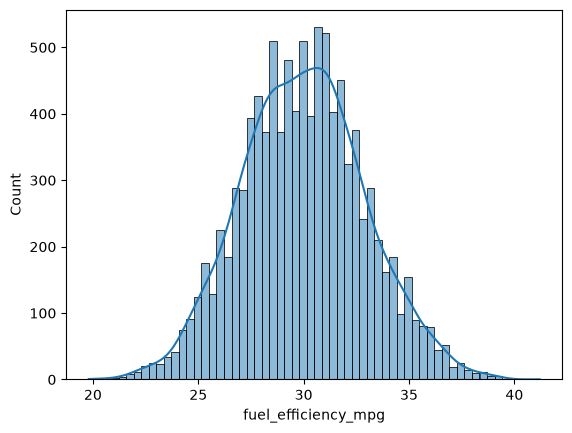

In [41]:
#EDA
sns.histplot(df["fuel_efficiency_mpg"], kde=True)
plt.show()

In [42]:
print("Skewness score:", df['fuel_efficiency_mpg'].skew())

Skewness score: 0.08080419601878173


In [43]:
missing_values = df.isnull().sum()
print(f"Missing values:\n{missing_values}")

Missing values:
engine_displacement      0
horsepower             877
vehicle_weight           0
model_year               0
fuel_efficiency_mpg      0
dtype: int64


In [44]:
median_hp = df['horsepower'].median()
print("Median for horsepower:", median_hp)

Median for horsepower: 254.0


In [45]:
def train_linear_regression(X, y):
    """Normal Equation"""
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])
    XTX = X.T @ X
    XTX_inv = np.linalg.inv(XTX)
    w = XTX_inv @ X.T @ y
    return w[0], w[1:]

def train_linear_regression_reg(X, y, r=0.0):
    """L2 Regularization (Ridge)"""
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])
    XTX = X.T @ X
    reg = r * np.identity(XTX.shape[0])
    XTX = XTX + reg
    XTX_inv = np.linalg.inv(XTX)
    w = XTX_inv @ X.T @ y
    return w[0], w[1:]

def rmse(y, y_pred):
    """RMSE"""
    error = y_pred - y
    mse = (error ** 2).mean()
    return np.sqrt(mse)

def prepare_X(df_subset, fill_value):
    """Eksik verileri doldurup matris üretme"""
    df_num = df_subset.copy()
    df_num = df_num.fillna(fill_value)
    return df_num.values

In [46]:
# %60 Train, %20 Val, %20 Test
n = len(df)
n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test
np.random.seed(42)
idx = np.arange(n)
np.random.shuffle(idx)
df_train = df.iloc[idx[:n_train]].reset_index(drop=True)
df_val = df.iloc[idx[n_train:n_train + n_val]].reset_index(drop=True)
df_test = df.iloc[idx[n_train + n_val:]].reset_index(drop=True)

In [47]:
# 'fuel_efficiency_mpg' = target variable
y_train = df_train['fuel_efficiency_mpg'].values
y_val = df_val['fuel_efficiency_mpg'].values
y_test = df_test['fuel_efficiency_mpg'].values

features = ['engine_displacement', 'horsepower', 'vehicle_weight', 'model_year']
df_train_feat = df_train[features]
df_val_feat = df_val[features]

In [50]:
# Q3: Missing Value Imputation (0 vs Mean)
# Filling with 0
X_train_0 = prepare_X(df_train_feat, fill_value=0)
w_0, w_vector_0 = train_linear_regression(X_train_0, y_train)
X_val_0 = prepare_X(df_val_feat, fill_value=0)
y_pred_0 = w_0 + X_val_0 @ w_vector_0
score_0 = round(rmse(y_val, y_pred_0), 3)

# Filling with the mean
mean_hp = df_train_feat['horsepower'].mean()
X_train_mean = prepare_X(df_train_feat, fill_value=mean_hp)
w_0_mean, w_vector_mean = train_linear_regression(X_train_mean, y_train)
X_val_mean = prepare_X(df_val_feat, fill_value=mean_hp)
y_pred_mean = w_0_mean + X_val_mean @ w_vector_mean
score_mean = round(rmse(y_val, y_pred_mean), 3)
print("Score mean:", score_mean)
print("--- QUESTION 3 RESULTS ---")
print(f"RMSE with 0: {score_0}")
print(f"RMSE with mean: {score_mean}")
if score_0 < score_mean:
    print("Option for Q3: With 0")
elif score_mean < score_0:
    print("Option for Q3: With mean")
else:
    print("Option for Q3: Both are equally good")

Score mean: 2.202
--- QUESTION 3 RESULTS ---
RMSE with 0: 2.205
RMSE with mean: 2.202
Option for Q3: With mean


In [51]:
# Q4: Regularized Linear Regression
r_values = [0, 0.01, 0.1, 1, 5, 10, 100]
r_results = {}

X_train_reg = prepare_X(df_train_feat, fill_value=0)
X_val_reg = prepare_X(df_val_feat, fill_value=0)
for r in r_values:
    w_0_r, w_vector_r = train_linear_regression_reg(X_train_reg, y_train, r=r)
    y_pred_r = w_0_r + X_val_reg @ w_vector_r
    score_r = round(rmse(y_val, y_pred_r), 4)
    r_results[r] = score_r

print("\n--- QUESTION 4 RESULTS ---")
for r, score in r_results.items():
    print(f"r={r:<5} -> RMSE: {score}")
best_r = min(r_results, key=r_results.get)
print(f"\nOption for Q4 (Best r): {best_r}")


--- QUESTION 4 RESULTS ---
r=0     -> RMSE: 2.2053
r=0.01  -> RMSE: 2.2058
r=0.1   -> RMSE: 2.2241
r=1     -> RMSE: 2.3492
r=5     -> RMSE: 2.4094
r=10    -> RMSE: 2.4195
r=100   -> RMSE: 2.4292

Option for Q4 (Best r): 0


In [52]:
def train_linear_regression(X, y):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])
    XTX = X.T @ X
    XTX_inv = np.linalg.inv(XTX)
    w = XTX_inv @ X.T @ y
    return w[0], w[1:]
def train_linear_regression_reg(X, y, r=0.0):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])
    XTX = X.T @ X
    reg = r * np.identity(XTX.shape[0])
    XTX = XTX + reg
    XTX_inv = np.linalg.inv(XTX)
    w = XTX_inv @ X.T @ y
    return w[0], w[1:]
def rmse(y, y_pred):
    error = y_pred - y
    mse = (error ** 2).mean()
    return np.sqrt(mse)
def prepare_X(df_subset):
    df_num = df_subset.copy()
    df_num = df_num.fillna(0)
    return df_num.values
features = ['engine_displacement', 'horsepower', 'vehicle_weight', 'model_year']

In [55]:
# Q5
seeds = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
scores = []
n = len(df)
n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test
for seed in seeds:
    np.random.seed(seed)
    idx = np.arange(n)
    np.random.shuffle(idx)

    df_train = df.iloc[idx[:n_train]].reset_index(drop=True)
    df_val = df.iloc[idx[n_train:n_train + n_val]].reset_index(drop=True)

    y_train = df_train['fuel_efficiency_mpg'].values
    y_val = df_val['fuel_efficiency_mpg'].values

    X_train = prepare_X(df_train[features])
    X_val = prepare_X(df_val[features])

    w_0, w_vector = train_linear_regression(X_train, y_train)
    y_pred = w_0 + X_val @ w_vector

    score = rmse(y_val, y_pred)
    scores.append(score)

std_score = round(np.std(scores), 3)
print("--- QUESTION 5 RESULT ---")
print("RMSE Scores:", np.array(scores).round(3))
print(f"Standard Deviation (std): {std_score}")

--- QUESTION 5 RESULT ---
RMSE Scores: [2.239 2.202 2.163 2.204 2.202 2.246 2.27  2.191 2.217 2.207]
Standard Deviation (std): 0.029


In [56]:
# Q6
np.random.seed(9)
idx = np.arange(n)
np.random.shuffle(idx)
df_train = df.iloc[idx[:n_train]].reset_index(drop=True)
df_val = df.iloc[idx[n_train:n_train + n_val]].reset_index(drop=True)
df_test = df.iloc[idx[n_train + n_val:]].reset_index(drop=True)

# Train and Validation
df_full_train = pd.concat([df_train, df_val]).reset_index(drop=True)
y_full_train = df_full_train['fuel_efficiency_mpg'].values
y_test = df_test['fuel_efficiency_mpg'].values
X_full_train = prepare_X(df_full_train[features])
X_test = prepare_X(df_test[features])

# Regularized Linear Regression training (r = 0.001)
w_0, w_vector = train_linear_regression_reg(X_full_train, y_full_train, r=0.001)
y_pred_test = w_0 + X_test @ w_vector
test_rmse = round(rmse(y_test, y_pred_test), 3)
print("\n--- QUESTION 6 RESULT ---")
print(f"Test Dataset RMSE: {test_rmse}")


--- QUESTION 6 RESULT ---
Test Dataset RMSE: 2.236
